In [1]:
import numpy as np
import pandas as pd
import swc.aeon.io as io
import swc.aeon.io.reader as reader
from swc.aeon.schema.streams import Device
from swc.aeon.schema import core as stream
from swc.aeon.io.reader import Csv
import swc.aeon.io.video as video
import os
from dotmap import DotMap
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice
import cv2

In [2]:
def get_camera_data(root: str, name: str):
    path = os.path.join(root, f"{name}/{name}.csv")
    data = pd.read_csv(path, header=0, names=["time"])
    data["_frame"] = data.index
    data["_path"] = os.path.splitext(path)[0] + ".avi"
    data.set_index("time", inplace=True)

    return data

def get_index_at_time(camera_data: pd.DataFrame, time: float):
    slice = camera_data.loc[camera_data.index <= time]
    return slice.iloc[[-1]]["_frame"].values[0]

def get_frame_at_index(camera_data: pd.DataFrame, index: int):
    return next(islice(camera_data, index, index+1))

def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs(np.dot(d1, d2) / np.sqrt(np.dot(d1, d1)*np.dot(d2, d2)))

## Landmark detection
def detect_landmarks(frame, blur: int, thresh1: int, thresh2: int):
    blurred = cv2.GaussianBlur(frame, (blur, blur), 0)
    edges = cv2.Canny(blurred, thresh1, thresh2)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    squares = []
    for cnt in contours:
        cnt_len = cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, 0.02 * cnt_len, True)
        if len(cnt) == 4 and cv2.contourArea(cnt) > 2000 and cv2.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos(cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4]) for i in range(4)])
            if max_cos < 0.3:
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                squares.append((cnt, (cx, cy)))

    return squares

In [ ]:
## Extract data from the subject camera
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T14-51-35/"
# base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-24T09-35-26/"

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

vid_path = os.path.join(base_dir, "AnnotatedResult.mp4")
result = pd.DataFrame(columns=["frame_index", "frame_time", "detected_squares", "track_centroid_x", "track_centroid_y", "track_area", "aruco_centroid_x", "aruco_centroid_y", "aruco_area"])

annotated_frames = []
n_squares = []
for f, frame in enumerate(subject_frames):
    detected_squares = 0
    blur = -1
    while detected_squares < 2:
        blur += 2
        squares = detect_landmarks(frame, blur, 200, 100)
        detected_squares = len(squares)
        if blur > 40:
            squares = detect_landmarks(frame, 1, 200, 100)
            break

    n_squares.append(len(squares))
    track_centroid = (np.nan, np.nan)
    aruco_centroid = (np.nan, np.nan)
    track_area = np.nan
    aruco_area = np.nan
    if (len(squares) == 2):
        track_contour = squares[0] if (squares[0][1][0] < squares[1][1][0]) else squares[1]
        aruco_contour = squares[1] if (squares[0][1][0] < squares[1][1][0]) else squares[0]

        track_centroid = track_contour[1]
        aruco_centroid = aruco_contour[1]
        track_area = cv2.contourArea(track_contour[0])
        aruco_area = cv2.contourArea(aruco_contour[0])
        contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
        contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
        contours = cv2.circle(contours, track_centroid, 2, (0, 255, 0), -1)
        contours = cv2.circle(contours, aruco_centroid, 2, (255, 0, 0), -1)
    else:
        contours = frame

    annotated_frames.append(contours)
    result.loc[f] = [f, subject_camera.index[f], len(squares), track_centroid[0], track_centroid[1], track_area, aruco_centroid[0], aruco_centroid[1], aruco_area]

video.export(annotated_frames, vid_path, 60)

print(result)

       frame_index  frame_time  detected_squares  track_centroid_x  \
0              0.0  511.149504               1.0               NaN   
1              1.0  514.610592               1.0               NaN   
2              2.0  514.617216               1.0               NaN   
3              3.0  514.623904               1.0               NaN   
4              4.0  514.630560               1.0               NaN   
...            ...         ...               ...               ...   
20641      20641.0  652.209696               2.0             367.0   
20642      20642.0  652.216352               2.0             367.0   
20643      20643.0  652.223072               2.0             367.0   
20644      20644.0  652.229696               2.0             367.0   
20645      20645.0  652.236352               2.0             367.0   

       track_centroid_y  track_area  aruco_centroid_x  aruco_centroid_y  \
0                   NaN         NaN               NaN               NaN   
1        

frame_index            10.00000
frame_time            514.67056
detected_squares        2.00000
track_centroid_x      368.00000
track_centroid_y      298.00000
track_area           2835.50000
aruco_centroid_x      497.00000
aruco_centroid_y      166.00000
aruco_area          20394.50000
Name: 10, dtype: float64
150.0
Max at 0.000000s


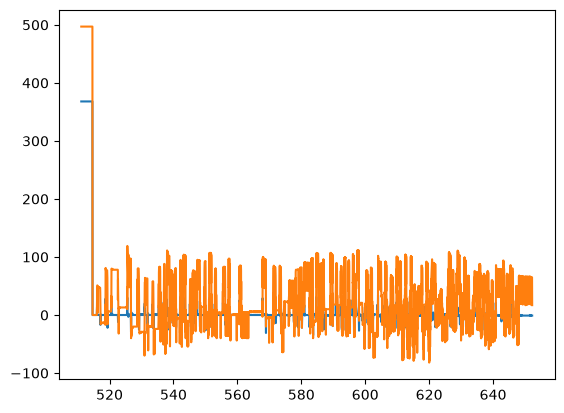

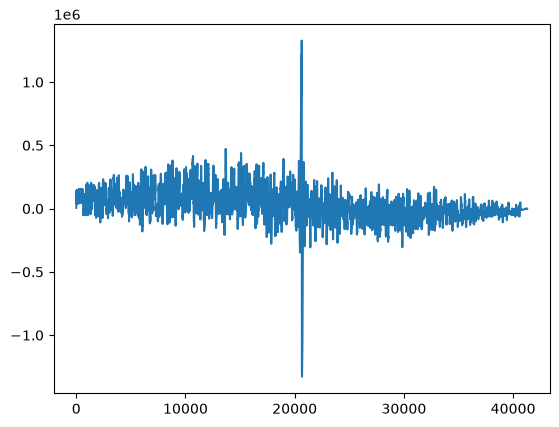

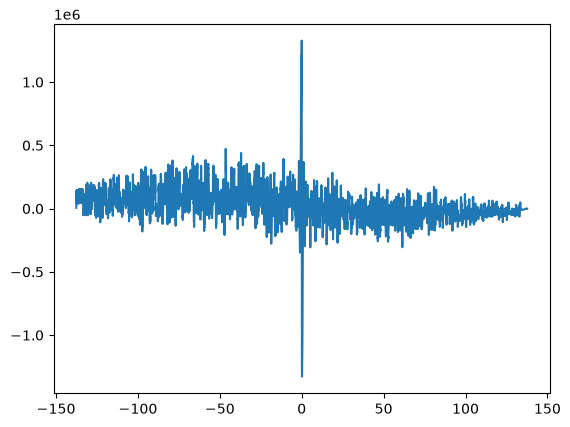

In [114]:
## Postprocessing
start_frame = 10
print(result.iloc[start_frame])

track_x = (result["track_centroid_x"]-result["track_centroid_x"].iloc[start_frame]).interpolate().fillna(result["track_centroid_x"].iloc[start_frame])
aruco_x = (result["aruco_centroid_x"]-result["aruco_centroid_x"].iloc[start_frame]).interpolate().fillna(result["aruco_centroid_x"].iloc[start_frame])
# fs = 1.0 / result["frame_time"].diff().mean()
fs = 150.0

print(fs)

plt.figure()
plt.plot(result["frame_time"], track_x)
plt.plot(result["frame_time"], aruco_x)

corr = np.correlate(track_x, aruco_x, mode='full')
lags = np.arange(-len(track_x) + 1, len(track_x)) / fs  # Convert lag to seconds
max_corr_idx = np.argmax(corr)
print(f'Max at {lags[max_corr_idx]:.6f}s')

plt.figure()
plt.plot(corr)

plt.figure()
plt.plot(lags,corr)